Vou fazer as seguintes análises com os dados disponíveis na pasta bases, sobre a Fórmula 1:
- Circuitos mais favoráveis a vitórias de escuderias específicas

    - Ferrari em Monza? Mercedes em Silverstone?

- Pilotos com mais vitórias em toda a história

    - Ranking absoluto de vitórias por piloto.


- Distribuição de pilotos por país ao longo das décadas

    - Ex: Brasil forte nos anos 80/90, Holanda em ascensão.

Antes de começar o código precisei instalar a biblioteca Pandas utilizando o comando a seguir:

In [ ]:
pip install pandas

Para conseguir montar o gráfico eu precisei installar a biblioteca matplotlib

In [ ]:
pip install matplotlib

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

Começando a primeira análise, sobre os circuitos mais favoráveis a vitórias de escuderias específicas.

Primeiramente, leio todas as bases que precisarei para fazer essa análise. Sendo elas:

- Corridas (`races.csv`)

- Construtores/Escuderias (`constructors.csv`)

- Resultados (`results.csv`)

- Circuitos (`circuits.csv`)

In [85]:
races = pd.read_csv("../bases/races.csv")
constructors = pd.read_csv("../bases/constructors.csv")
results = pd.read_csv("../bases/results.csv")
circuits = pd.read_csv("../bases/circuits.csv")

Depois eu pego apenas os ganhadores das corridas, na base de resultado:

In [86]:
winners = results[results["positionText"] == "1"]

Junto a base de corridas com base no Ids já presente na base de resultados, somente para conseguir juntar a base de circuitos, onde vou pegar seu nome e definir o nome da coluna como "circuitName".

In [87]:
winners = winners.merge(races[["raceId","circuitId"]], on="raceId", how="left")
winners = winners.merge(circuits[["circuitId", "name"]], on="circuitId", how="left")
winners.rename(columns={"name": "circuitName"}, inplace=True)

Depois junto a base de contrutores/escuderias, com base nos Ids já presente em `results.csv`, para pegar seus nomes. Vou, posteriormente, redefinir o nome da coluna para "constructorName"

In [88]:
winners = winners.merge(constructors[["constructorId", "name"]], on="constructorId", how="left")
winners.rename(columns={"name": "constructorName"}, inplace=True)

Com todas as informações necessárias unidas no dataframe `winners`, conto a quantidade de vezes que cada escuderia/construtor venceu cada circuito. Faço isso agrupando pelas colunas `constructorName` e `circuitName`.

In [89]:
victories_by_team_circuit = (
    winners.groupby(["constructorName", "circuitName"])
    .size()
    .reset_index(name="win_count")
    .sort_values(by="win_count", ascending=False)
)

In [90]:
victories_by_team_circuit

,constructorName,circuitName,win_count
95,Ferrari,Autodromo Nazionale di Monza,20
212,McLaren,Circuit de Monaco,15
131,Ferrari,Silverstone Circuit,15
112,Ferrari,Circuit de Spa-Francorchamps,14
124,Ferrari,Nürburgring,14
...,...,...,...
31,Benetton,Hungaroring,1
407,Williams,Circuit Park Zandvoort,1
413,Williams,Circuito de Jerez,1
414,Williams,Detroit Street Circuit,1


Agora começando a parte do plot dos dados extraídos e tratados com base nos dados presentes.

Começo fazendo o tratamento do dataframe, pivotando os dados, fazendo as linhas serem escuderias, as colunas serem circuitos e os valores serem o número de vitória.


In [91]:
pivot_df = victories_by_team_circuit.pivot_table(
    index="constructorName",
    columns="circuitName",
    values="win_count",
    fill_value=0
)

Depois defino o tamanho do gráfico, faço uma linha no gráfico para cada escuderia, defino o nome do gráfico, legendas e estilo do gráfico. Por fim, mostro o gráfico.

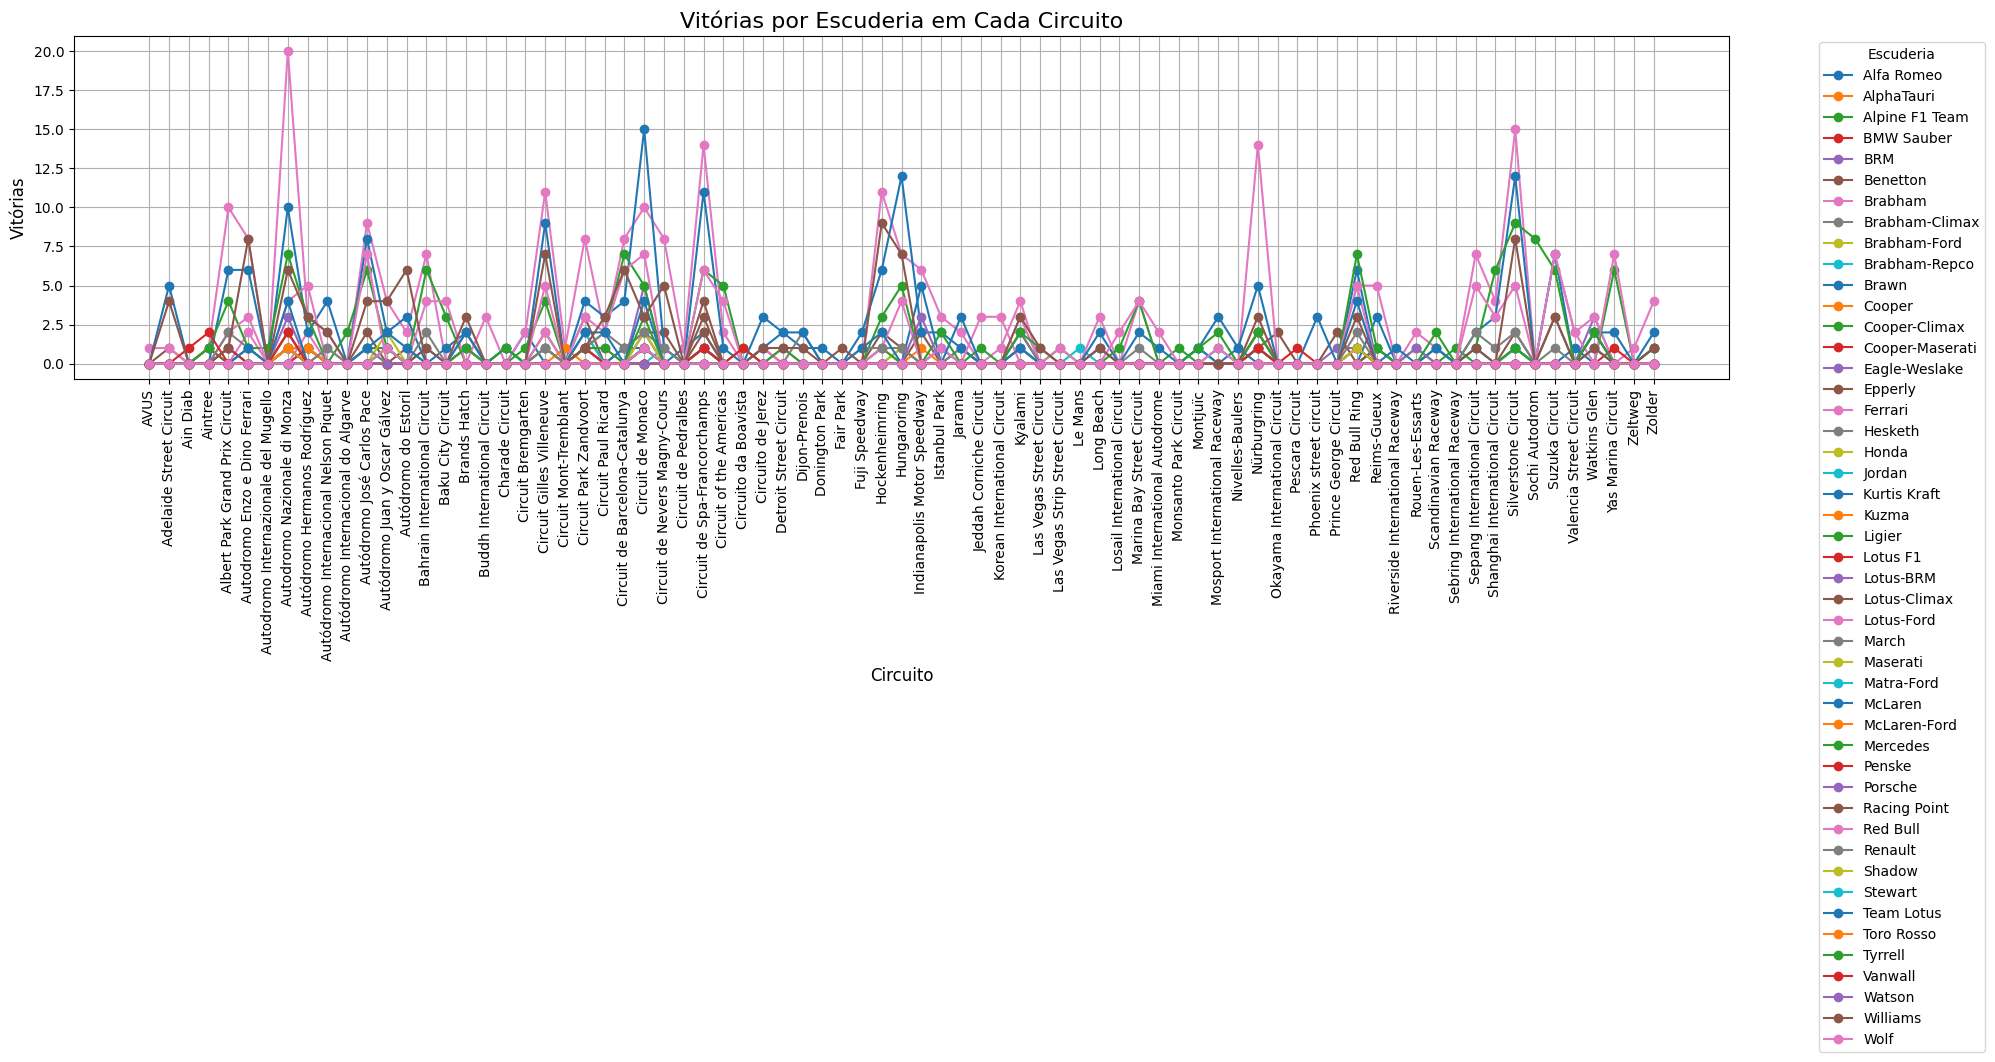

In [92]:
plt.figure(figsize=(20, 8))

for team in pivot_df.index:
    plt.plot(pivot_df.columns, pivot_df.loc[team], marker='o', label=team)

plt.title("Vitórias por Escuderia em Cada Circuito", fontsize=16)
plt.xlabel("Circuito", fontsize=12)
plt.ylabel("Vitórias", fontsize=12)
plt.xticks(rotation=90)
plt.legend(title="Escuderia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

Como é possível perceber o gráfico mostrado possui muitas informações, tanto nas linhas, quanto no eixo X, então decido mostrar esse gráfico apenas das 5 escuderias com mais vitórias nos 10 circuitos com mais corridas. Para isso preciso fazer novamente mais tratamento dos dados em `victories_by_team_circuit`

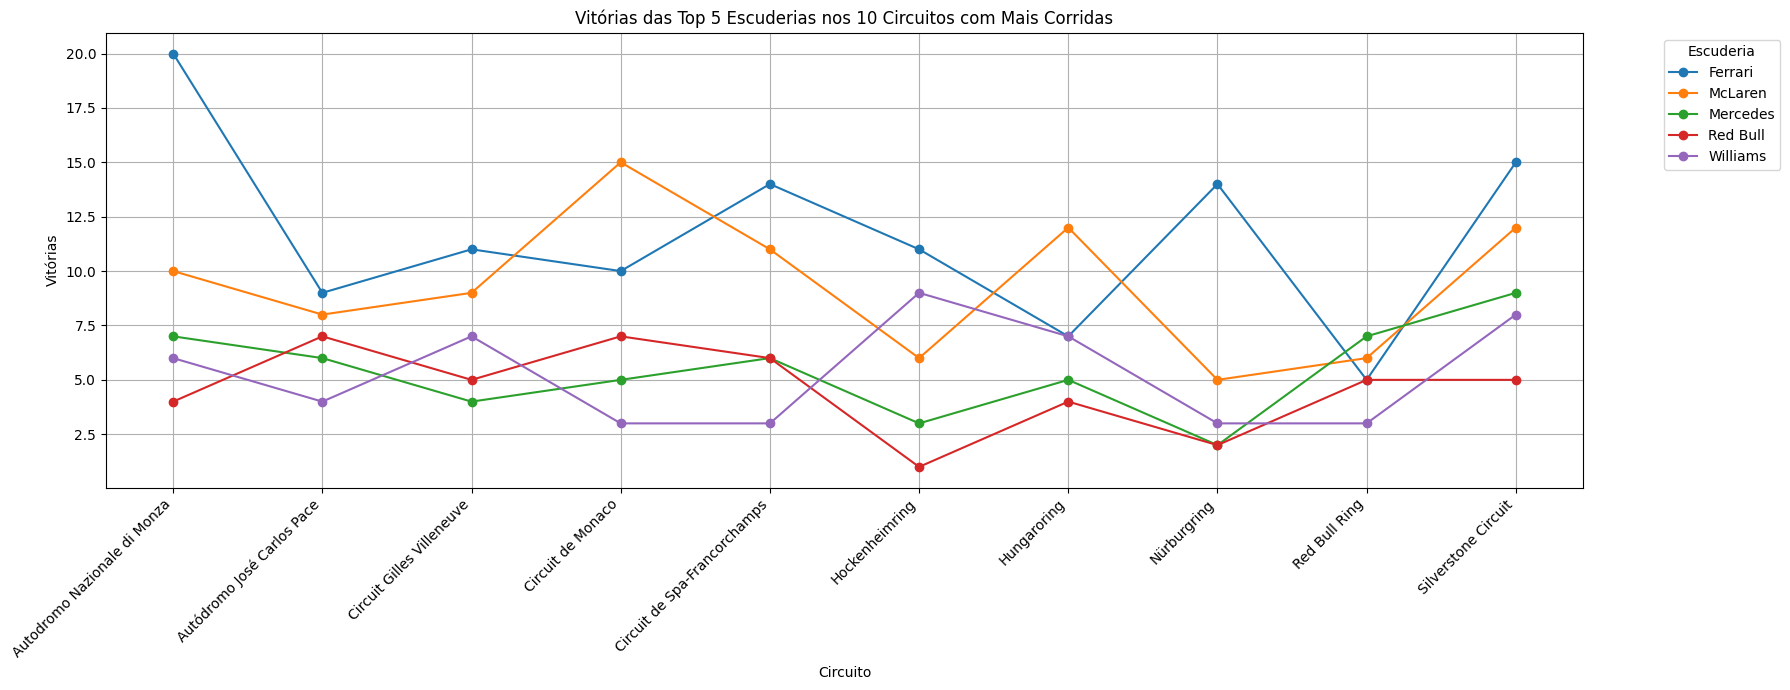

In [93]:
top_teams = (
    victories_by_team_circuit.groupby("constructorName")["win_count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered_teams = victories_by_team_circuit[victories_by_team_circuit["constructorName"].isin(top_teams)]

top_circuits = (
    races["circuitId"]
    .value_counts()
    .head(10)
    .index
)
top_circuit_names = circuits[circuits["circuitId"].isin(top_circuits)]["name"].tolist()
filtered_data = filtered_teams[filtered_teams["circuitName"].isin(top_circuit_names)]

pivot_df = filtered_data.pivot_table(
    index="constructorName",
    columns="circuitName",
    values="win_count",
    fill_value=0
)

plt.figure(figsize=(18, 7))

for team in pivot_df.index:
    plt.plot(pivot_df.columns, pivot_df.loc[team], marker='o', label=team)

plt.title("Vitórias das Top 5 Escuderias nos 10 Circuitos com Mais Corridas")
plt.xlabel("Circuito")
plt.ylabel("Vitórias")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title="Escuderia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Como há muita informação, vou especificar se o dado retirado será do total, ou apenas a visão do top 5 escuderias. Com isso definido, vou pegar algumas estatísticas descritivas, sendo elas:

- Média de vitórias por escuderia (Somente top 5)

- Circuito com maior variação de escuderias vencedoras (Dentro de todos circuitos)

- Moda dos circuitos por escuderia, circuitos que cada escuderia mais venceu (Todas escuderias)

Média

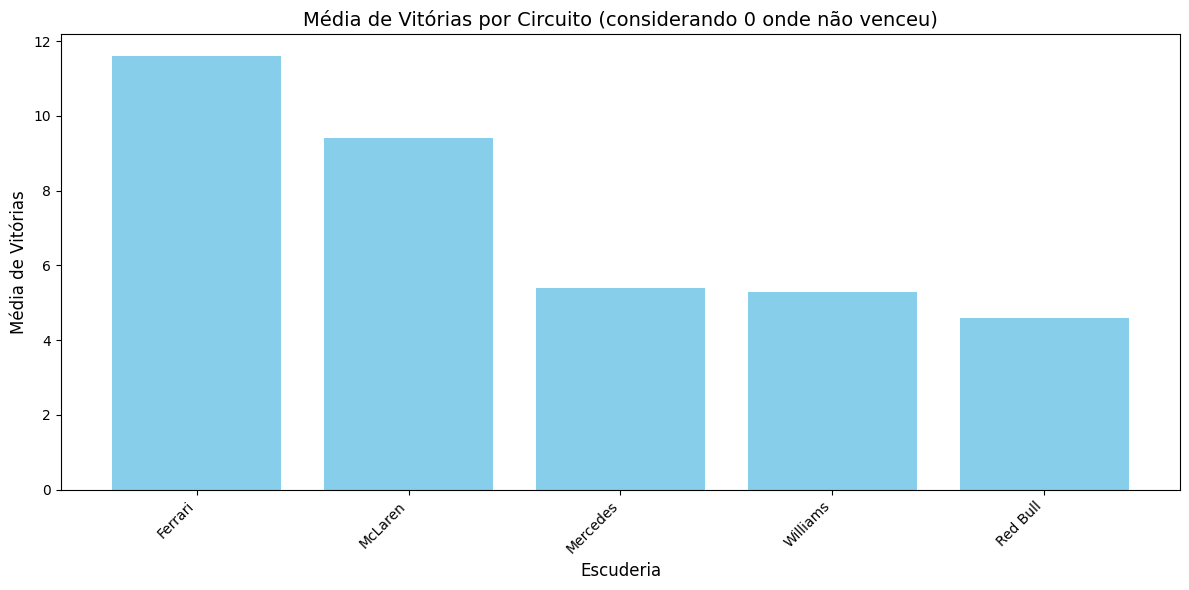

In [94]:
all_combinations = pd.MultiIndex.from_product(
    [top_teams, top_circuit_names],
    names=["constructorName", "circuitName"]
).to_frame(index=False)

full_data = all_combinations.merge(
    victories_by_team_circuit, how="left", on=["constructorName", "circuitName"]
).fillna({"win_count": 0})

mean_with_zeros = full_data.groupby("constructorName")["win_count"].mean().reset_index(name="mean_wins")

mean_with_zeros_sorted = mean_with_zeros.sort_values(by="mean_wins", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(mean_with_zeros_sorted["constructorName"], mean_with_zeros_sorted["mean_wins"], color='skyblue')

plt.title("Média de Vitórias por Circuito (considerando 0 onde não venceu)", fontsize=14)
plt.xlabel("Escuderia", fontsize=12)
plt.ylabel("Média de Vitórias", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

Circuito com maior vairiação de escuderias vencedoras

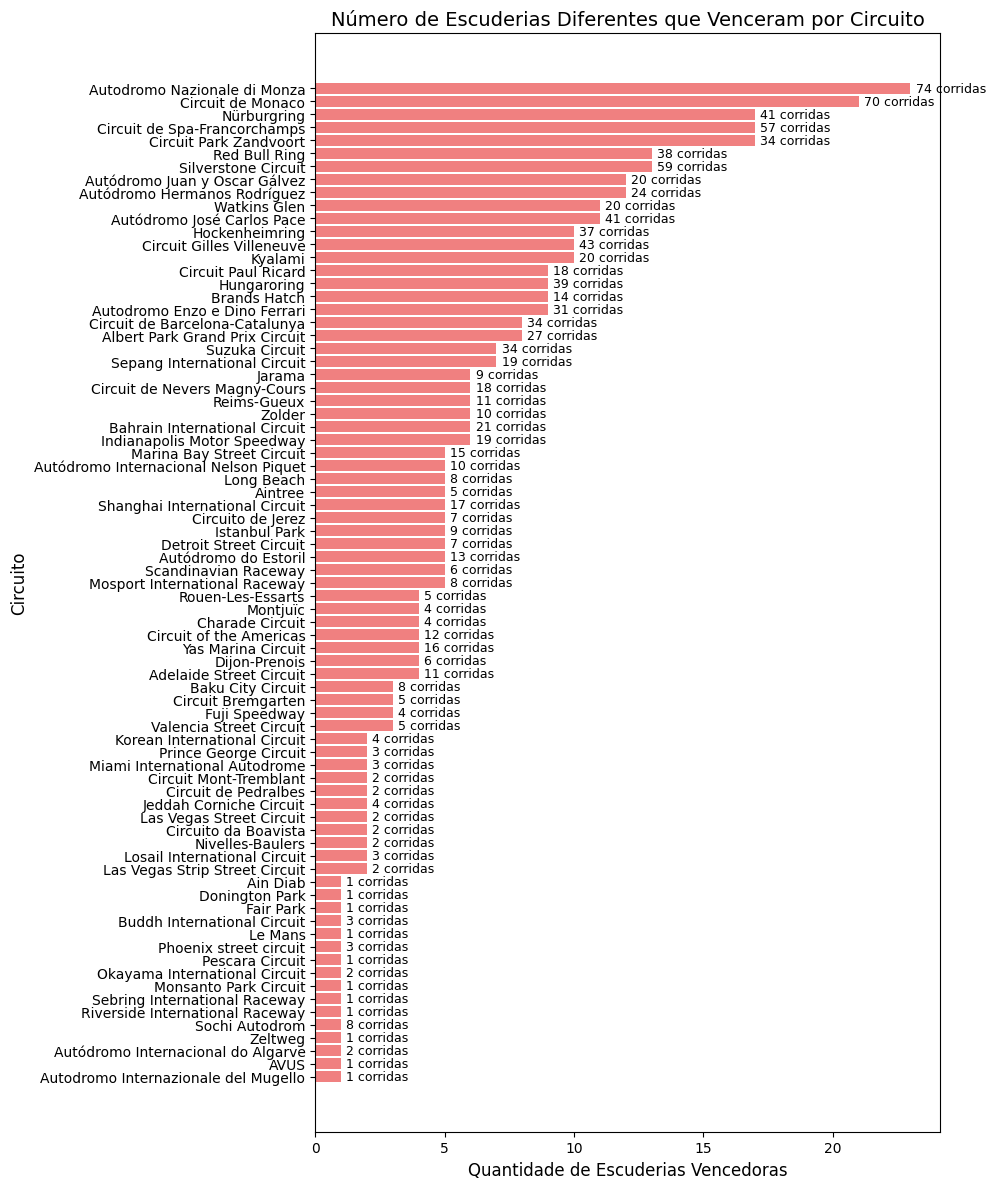

In [95]:
unique_winners_per_circuit = (
    victories_by_team_circuit.groupby("circuitName")["constructorName"]
    .nunique()
    .reset_index(name="unique_winning_teams")
    .sort_values(by="unique_winning_teams", ascending=False)
)

sorted_circuits = unique_winners_per_circuit.sort_values(by="unique_winning_teams", ascending=True)

races_per_circuit = races.groupby("circuitId").size().reset_index(name="race_count")
races_with_names = races_per_circuit.merge(circuits[["circuitId", "name"]], on="circuitId")

circuit_stats = sorted_circuits.merge(races_with_names, left_on="circuitName", right_on="name")

plt.figure(figsize=(10, 12))
bars = plt.barh(circuit_stats["circuitName"], circuit_stats["unique_winning_teams"], color="lightcoral")

plt.title("Número de Escuderias Diferentes que Venceram por Circuito", fontsize=14)
plt.xlabel("Quantidade de Escuderias Vencedoras", fontsize=12)
plt.ylabel("Circuito", fontsize=12)

for bar, races in zip(bars, circuit_stats["race_count"]):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{races} corridas", va='center', fontsize=9)

plt.tight_layout()
plt.show()

Moda dos circuitos por escuderia, circuitos que cada escuderia mais venceu

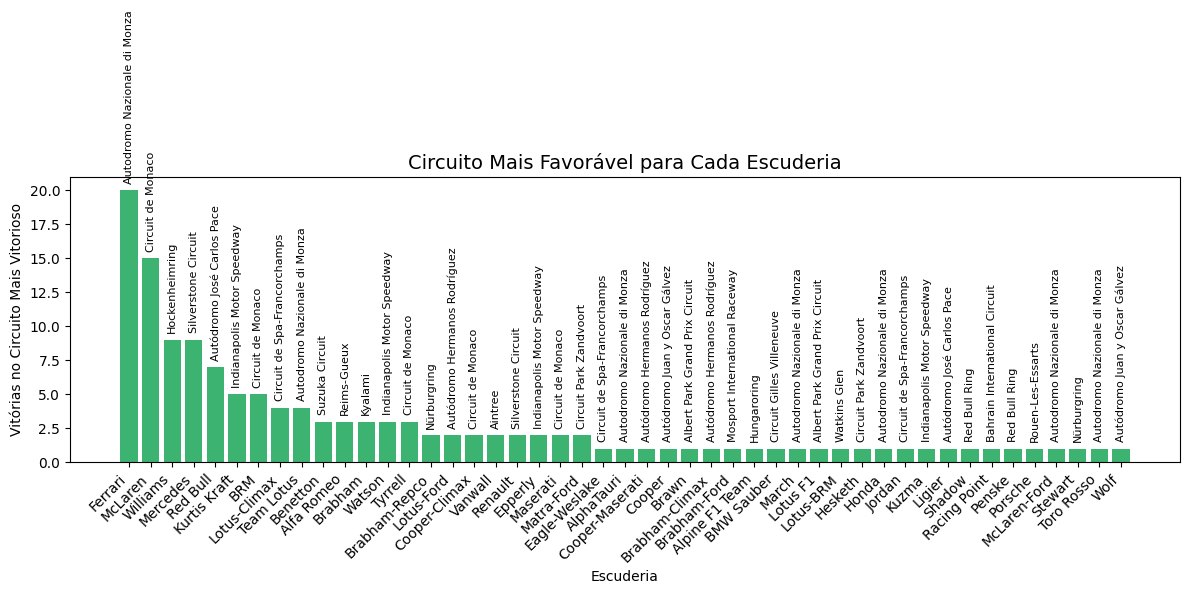

In [96]:
team_mode = victories_by_team_circuit.loc[victories_by_team_circuit.groupby("constructorName")["win_count"].idxmax()].reset_index(drop=True).rename(columns={"circuitName": "most_won_circuit", "win_count": "wins_in_that_circuit"})[["constructorName", "most_won_circuit", "wins_in_that_circuit"]]
team_mode_sorted = team_mode.sort_values(by="wins_in_that_circuit", ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(team_mode_sorted["constructorName"], team_mode_sorted["wins_in_that_circuit"], color="mediumseagreen")

for bar, circuit in zip(bars, team_mode_sorted["most_won_circuit"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             circuit, ha='center', va='bottom', fontsize=8, rotation=90)

plt.title("Circuito Mais Favorável para Cada Escuderia", fontsize=14)
plt.xlabel("Escuderia")
plt.ylabel("Vitórias no Circuito Mais Vitorioso")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Algumas correlações observáveis no conjunto de dados apresentado são:
- Correlação indireta entre número de corridas e diversidade de escuderias vencedoras:
    - Circuitos com mais etapas disputadas ao longo dos anos (como Monza, Mônaco, Spa) tendem a apresentar maior número de escuderias diferentes com vitórias, o que sugere que o tempo de permanência no calendário favorece a alternância de dominância.
- Circuitos históricos tendem a gerar distribuição mais ampla de vitórias:
    - Por exemplo, Monza teve 23 escuderias diferentes como vencedoras, sendo também o circuito com o maior número de corridas realizadas — reforçando essa correlação entre tempo no calendário e variedade de vencedores.
- Correlação negativa entre variância e vitórias concentradas:
    - Escuderias como Ferrari ou McLaren mostram variância maior, indicando domínio muito forte em alguns circuitos específicos (ex: Ferrari em Monza), mas desempenho mais fraco ou inexistente em outros.
- Ferrari apresenta a maior média de vitórias por circuito:
    - Mesmo considerando os circuitos em que nunca venceu. Isso indica amplitude de desempenho ao longo do calendário e longevidade como participante ativa da F1.

Alguns insights dentro também do mesmo conjunto de dados:
- Ferrari é historicamente dominante em Monza, com 20 vitórias — sendo o circuito mais vitorioso para a escuderia e também o que mais escuderias diferentes venceram, indicando competitividade histórica com leve domínio da equipe italiana.
- McLaren tem em Mônaco seu circuito mais vitorioso, o que sugere especialização em circuitos de rua em determinadas épocas da F1, diferentemente de Red Bull, que se destaca em Interlagos.
- Circuitos com maior número de corridas tendem a apresentar maior número de escuderias vencedoras, o que é esperado, mas reforça que rotatividade no calendário pode influenciar o monopólio ou a diversidade dos resultados.
- Escuderias com mais vitórias absolutas nem sempre são as com melhor média por circuito, especialmente se considerarmos circuitos onde não venceram — o que destaca a importância de analisar consistência e amplitude de desempenho, não apenas o total acumulado.

Agora vou começar a parte de pilotos com mais vitórias em toda a história

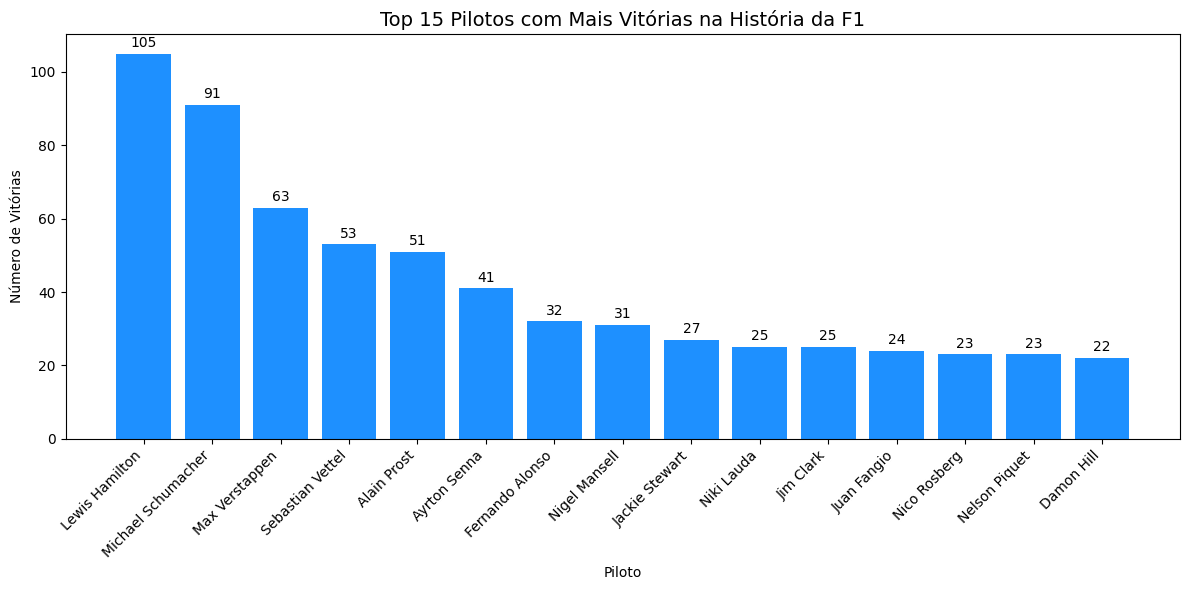

In [97]:
results = pd.read_csv("../bases/results.csv")
drivers = pd.read_csv("../bases/drivers.csv")
winners = results[results["positionOrder"] == 1]

driver_wins = winners.groupby("driverId").size().reset_index(name="win_count")

driver_wins = driver_wins.merge(drivers, on="driverId")

driver_wins["driver_name"] = driver_wins["forename"] + " " + driver_wins["surname"]

driver_wins = driver_wins.sort_values(by="win_count", ascending=False)

top_15 = driver_wins.head(15)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_15["driver_name"], top_15["win_count"], color="dodgerblue")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

plt.title("Top 15 Pilotos com Mais Vitórias na História da F1", fontsize=14)
plt.xlabel("Piloto")
plt.ylabel("Número de Vitórias")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

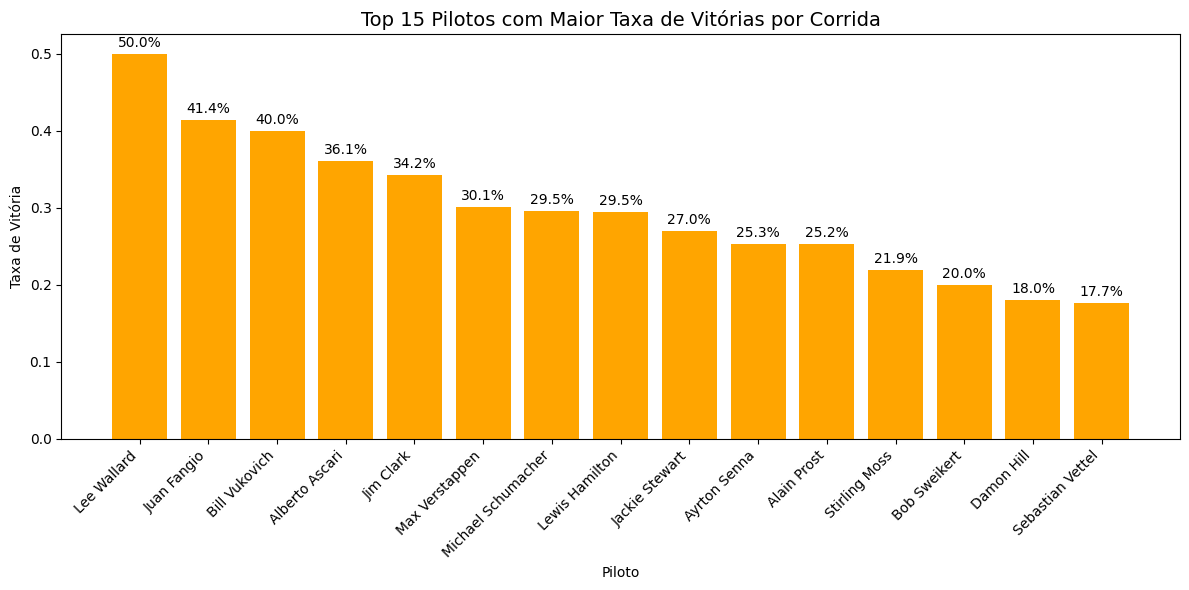

In [98]:
results = pd.read_csv("../bases/results.csv")
drivers = pd.read_csv("../bases/drivers.csv")

races_by_driver = results.groupby("driverId").size().reset_index(name="total_races")

wins_by_driver = results[results["positionOrder"] == 1].groupby("driverId").size().reset_index(name="wins")

driver_stats = races_by_driver.merge(wins_by_driver, on="driverId", how="left").fillna(0)

driver_stats["win_rate"] = driver_stats["wins"] / driver_stats["total_races"]

driver_stats = driver_stats.merge(drivers, on="driverId")
driver_stats["driver_name"] = driver_stats["forename"] + " " + driver_stats["surname"]

top_15_winrate = driver_stats.sort_values(by="win_rate", ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_15_winrate["driver_name"], top_15_winrate["win_rate"], color="orange")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.1%}", ha='center', va='bottom')

plt.title("Top 15 Pilotos com Maior Taxa de Vitórias por Corrida", fontsize=14)
plt.xlabel("Piloto")
plt.ylabel("Taxa de Vitória")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Correlações:

- A eficiência (win rate) e o volume (número total de vitórias) são métricas complementares e não necessariamente correlacionadas. Por exemplo, um piloto pode ter poucas vitórias, mas uma taxa altíssima por ter disputado poucas corridas, como é o caso do maior win rate (Lee Wallard).

Insight:

- O gráfico de vitórias absolutas mostra que Lewis Hamilton é o piloto com mais vitórias na história da F1, seguido por Schumacher. Isso reflete não só talento individual, mas também longevidade e constância em equipes competitivas.

- Já na análise de taxa de vitória, aparecem pilotos com menos corridas mas altíssimo desempenho, como Ascari, Fangio ou Clark, que corriam em eras com menos provas por temporada e, muitas vezes, com maior disparidade entre carros. Esses pilotos podem não figurar no top absoluto de vitórias, mas demonstram domínio estatístico impressionante.

- Hamilton é destaque nos dois gráficos, aparecendo tanto no topo de vitórias quanto com uma taxa de vitória superior a muitos campeões históricos, o que reforça seu desempenho como um dos mais completos da F1.

Para a última análise precisei fazer o download de mais uma biblioteca `seaborn`

In [ ]:
pip install seaborn

Com essa biblioteca, após tratar os dados para pegar os pilotos únicos de cada país por cada década, mostrarei os dados através de um heatmap.

In [99]:
drivers = pd.read_csv("../bases/drivers.csv")
results = pd.read_csv("../bases/results.csv")
races = pd.read_csv("../bases/races.csv")

results = results.merge(races[["raceId", "year"]], on="raceId", how="left")

results = results.merge(drivers[["driverId", "nationality"]], on="driverId", how="left")

results["decade"] = (results["year"] // 10) * 10

unique_pilots_per_country_decade = (
    results.groupby(["decade", "nationality"])["driverId"]
    .nunique()
    .reset_index(name="unique_drivers")
)
pivot_df = unique_pilots_per_country_decade.pivot(index="decade", columns="nationality", values="unique_drivers").fillna(0)

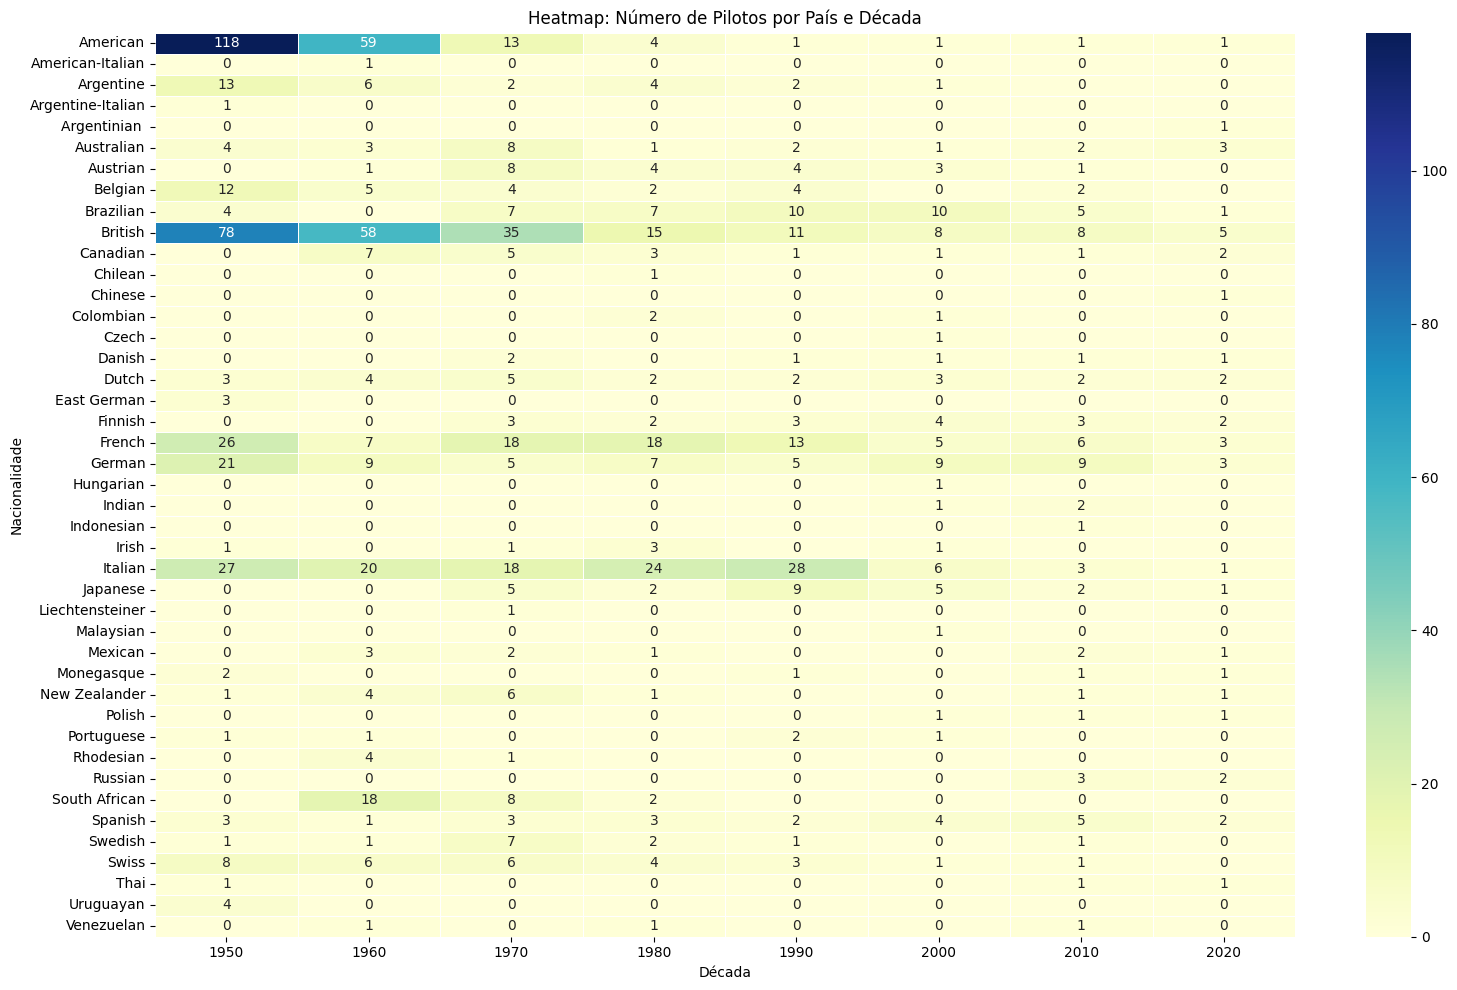

In [100]:
import seaborn as sns

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_df.T, annot=True, fmt="g", cmap="YlGnBu", linewidths=0.5)

plt.title("Heatmap: Número de Pilotos por País e Década")
plt.xlabel("Década")
plt.ylabel("Nacionalidade")
plt.tight_layout()
plt.show()

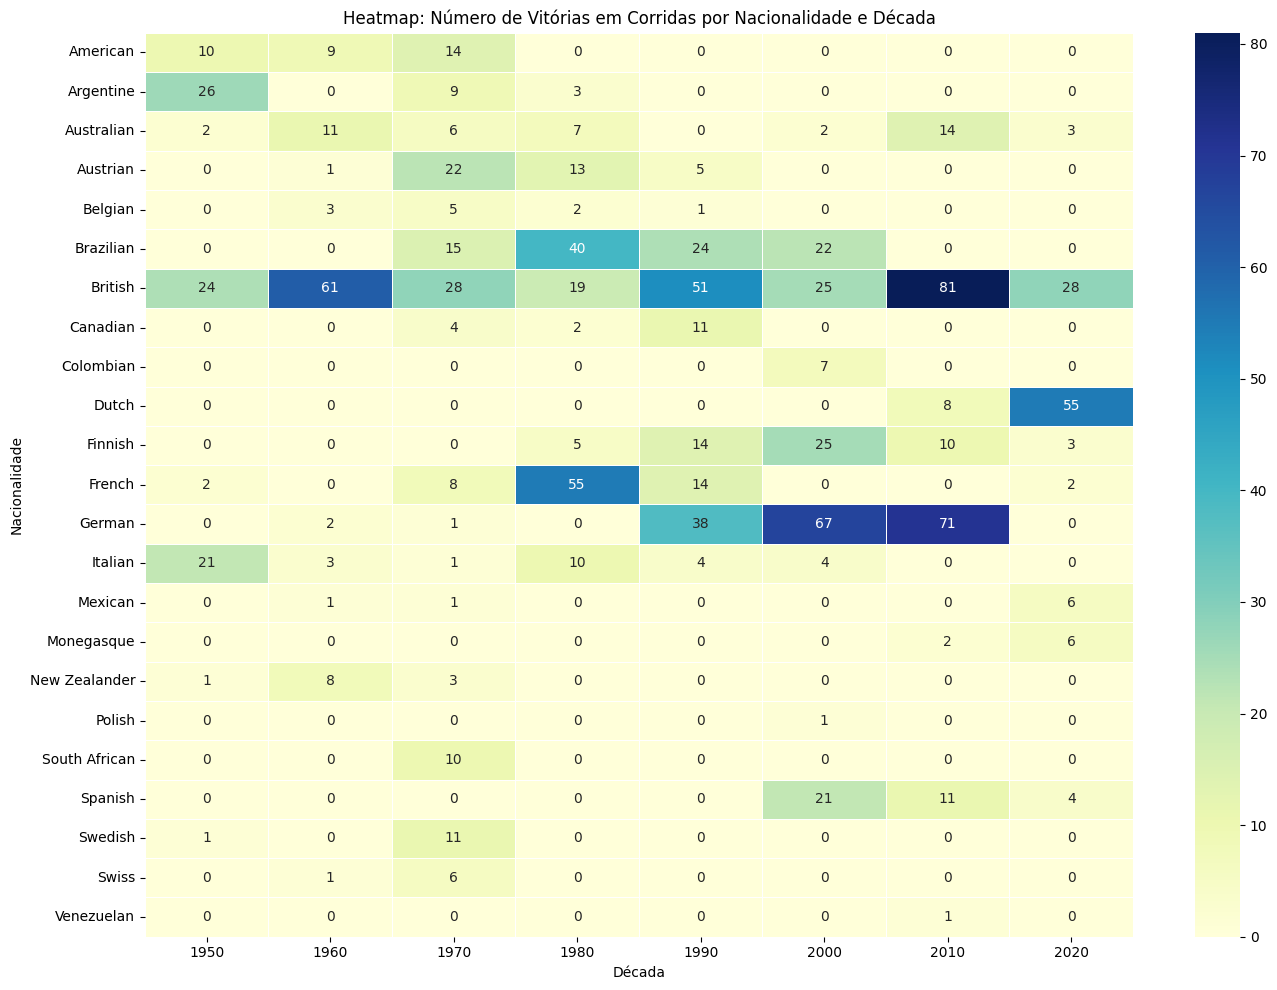

In [101]:
results = pd.read_csv("../bases/results.csv")
races = pd.read_csv("../bases/races.csv")
drivers = pd.read_csv("../bases/drivers.csv")

winners = results[results["positionOrder"] == 1]

winners = winners.merge(races[["raceId", "year"]], on="raceId", how="left")

winners = winners.merge(drivers[["driverId", "nationality"]], on="driverId", how="left")

winners["decade"] = (winners["year"] // 10) * 10

wins_per_nation = winners.groupby(["decade", "nationality"]).size().reset_index(name="win_count")

heatmap_data = wins_per_nation.pivot(index="nationality", columns="decade", values="win_count").fillna(0)

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt="g", cmap="YlGnBu", linewidths=0.5)

plt.title("Heatmap: Número de Vitórias em Corridas por Nacionalidade e Década")
plt.xlabel("Década")
plt.ylabel("Nacionalidade")
plt.tight_layout()
plt.show()

Correlações:
- Quantidade de pilotos ≠ quantidade de vitórias: Embora países como os Estados Unidos e Reino Unido tenham tido uma grande quantidade de pilotos nas décadas de 1950 e 1960, o número de vitórias dos americanos foi relativamente baixo. Isso mostra que um alto número de participantes não garante desempenho competitivo, destacando a importância de equipes e estrutura técnica.
- Correlação entre hegemonia de escuderias e vitórias nacionais: A ascensão de determinadas nacionalidades em certas décadas está fortemente ligada ao sucesso de escuderias específicas. Por exemplo:

    - Brasil nos anos 80/90 com Nelson Piquet, Ayrton Senna e equipes como Williams e McLaren.

    - Alemanha nos anos 2000/2010 com Schumacher (Ferrari) e Vettel (Red Bull).

    - Reino Unido em praticamente todas as décadas, refletindo a presença de equipes dominantes como McLaren, Williams e Mercedes, além de talentos britânicos recorrentes.

- Ciclos de domínio nacional: Nota-se que algumas nacionalidades apresentam ciclos de auge bem definidos:

    - Argentina nas décadas de 1950 (com Fangio).

    - França na década de 1980.

    - Finlândia entre 1990 e 2010.

    - Holanda aparece com destaque apenas na década de 2020 (Verstappen), ilustrando como um único piloto pode colocar um país em evidência.

- Diversidade de países campeões diminuiu nas décadas recentes, com uma concentração maior de vitórias em menos nacionalidades, principalmente Reino Unido, Alemanha e Holanda, refletindo maior competitividade e excelência em poucos polos automobilísticos.

Insights
- Décadas recentes têm menos pilotos no geral, mas com maior taxa de vitórias concentradas em poucos nomes. Isso pode indicar um cenário mais elitizado e competitivo, onde apenas pilotos com suporte técnico e patrocínio de ponta conseguem se destacar.

- O domínio britânico é consistente e resiliente, com vitórias em todas as décadas desde 1950, demonstrando tradição, infraestrutura, e constante renovação de talentos.

- O Brasil, mesmo com queda no número de pilotos nas últimas décadas, permanece relevante na história da F1 devido ao seu desempenho de destaque entre 1980 e 2000.

- Países emergentes como Holanda e Mônaco mostram que, embora historicamente ausentes, é possível conquistar protagonismo global com talento individual aliado a boas equipes.